# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import *
from data_fit import *
from data_plot import *
import scipy
pi = np.pi 

# Data

In [2]:
# n_L effect
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C"
Exp292_6_10C = BM26_experiment(experiment_path)
Info292_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_10C"
Exp292_12_10C = BM26_experiment(experiment_path)
Info292_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

# N_bb efect
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_576_24_Cryst_at_15C"
Exp576_24_15C = BM26_experiment(experiment_path)

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_888_24_Cryst_at_15C"
Exp888_24_15C = BM26_experiment(experiment_path)


experiment_path = r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\BM26\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

experiment_path = r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\BM26\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)
Info292_24_15C = read_Samodelkin_info(r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv")

experiment_path = r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\BM26\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)
Info292_24_20C = read_Samodelkin_info(r"C:\Users\LabPC\PythonProjects\PEG_PNIPAM_crystallization\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_20C.csv")

NameError: name 'read_Samodelkin_info' is not defined

# Functions

In [135]:
def Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+log_normal_peak(x, I0, q0, s)

def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))
    

In [217]:
def sigmoid(x, A, alpha, m):
  """
  Calculates the sigmoid function for a given input x.
  """
  return A / (1 + np.exp(-alpha*(x-m)))

# Analysis

### 292-6 10C

Text(0, 0.5, 'Crystallinity')

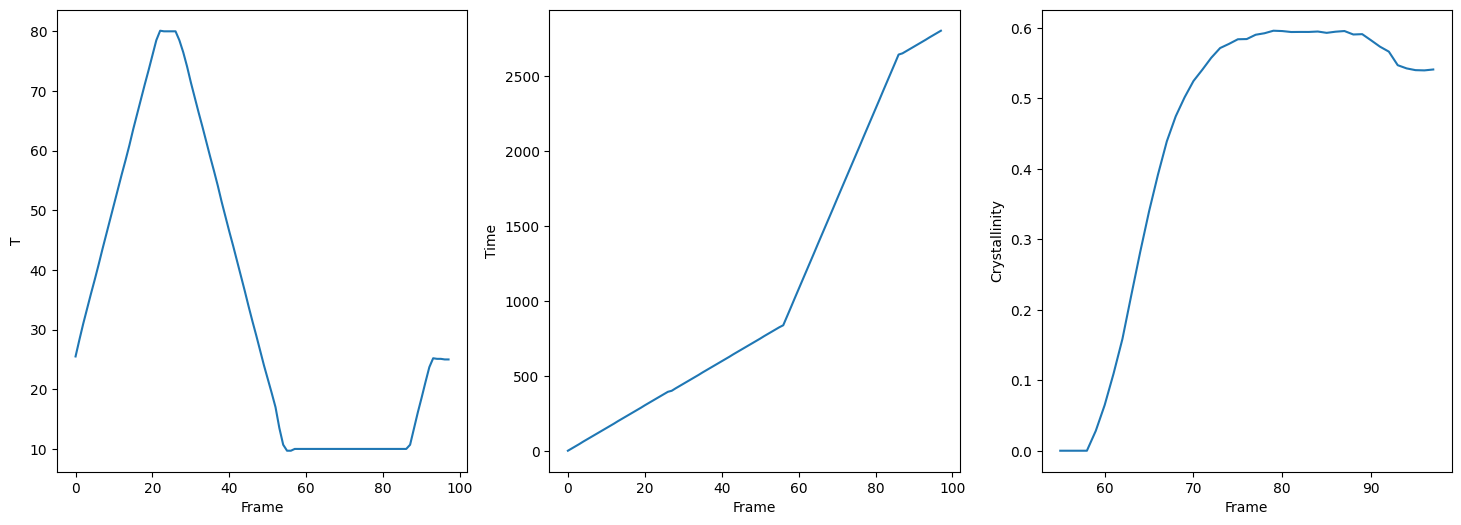

In [78]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_6_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 57: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0057.dat
Чтение WAXS файла 60: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0060.dat
Чтение WAXS файла 63: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0063.dat
Чтение WAXS файла 66: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0066.dat
Чтение WAXS файла 70: PEG_PNIPAM_292_6_Cryst_at_10C_WAXS_0070.dat


(-0.1, 11.0)

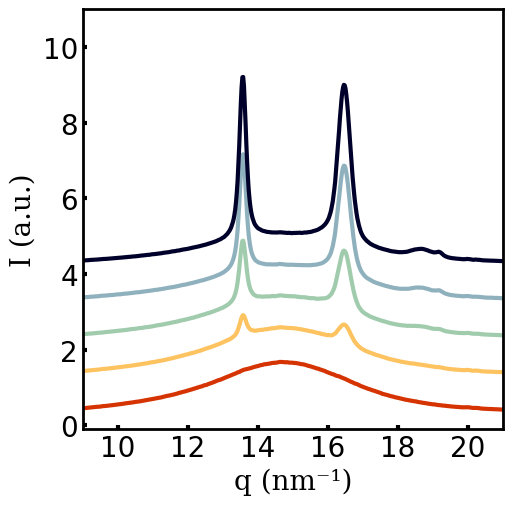

In [3]:
WAXS_plot(6,6)

lnwdth = 3
q, I = Exp292_6_10C.get_1d_WAXS(57)
plt.plot(q, I/1000 , linewidth=lnwdth, color='#D53302')

q, I = Exp292_6_10C.get_1d_WAXS(60)
plt.plot(q, I/1000 + 1, linewidth=lnwdth, color='#FDC360')

q, I = Exp292_6_10C.get_1d_WAXS(63)
plt.plot(q, I/1000 + 2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp292_6_10C.get_1d_WAXS(66)
plt.plot(q, I/1000 + 3, linewidth=lnwdth, color='#8FB1BD')

q, I = Exp292_6_10C.get_1d_WAXS(70)
plt.plot(q, I/1000 + 4, linewidth=lnwdth, color='#00012A')

plt.xlim(9, 21)
plt.ylim(-0.1, 11)

Чтение SAXS файла 57: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0057.dat
Чтение SAXS файла 60: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0060.dat
Чтение SAXS файла 63: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0063.dat
Чтение SAXS файла 66: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0066.dat
Чтение SAXS файла 70: PEG_PNIPAM_292_6_Cryst_at_10C_SAXS_0070.dat


(0.008, 1300.0)

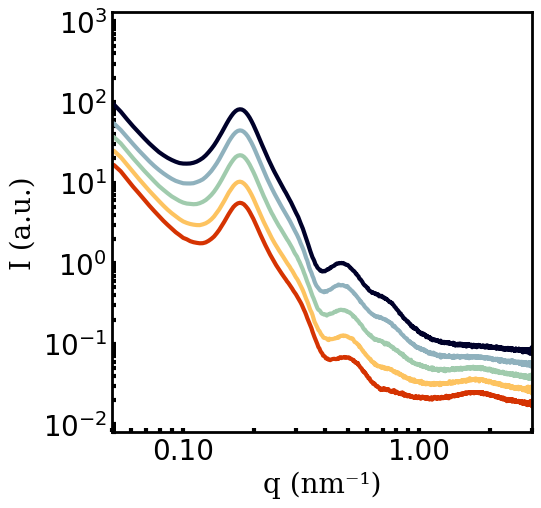

In [121]:
SAXS_plot(6,6)

lnwdth = 3
k = 1.5

q, I = Exp292_6_10C.get_1d_SAXS(57)
plt.plot(q, I, linewidth=lnwdth, color='#D53302')

q, I = Exp292_6_10C.get_1d_SAXS(60)
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360')

q, I = Exp292_6_10C.get_1d_SAXS(63)
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp292_6_10C.get_1d_SAXS(66)
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD')

q, I = Exp292_6_10C.get_1d_SAXS(70)
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A')

plt.xlim(0.05, 3)
plt.ylim(0.8e-2, 13e2)

### 292_12 10C

Text(0, 0.5, 'Crystallinity')

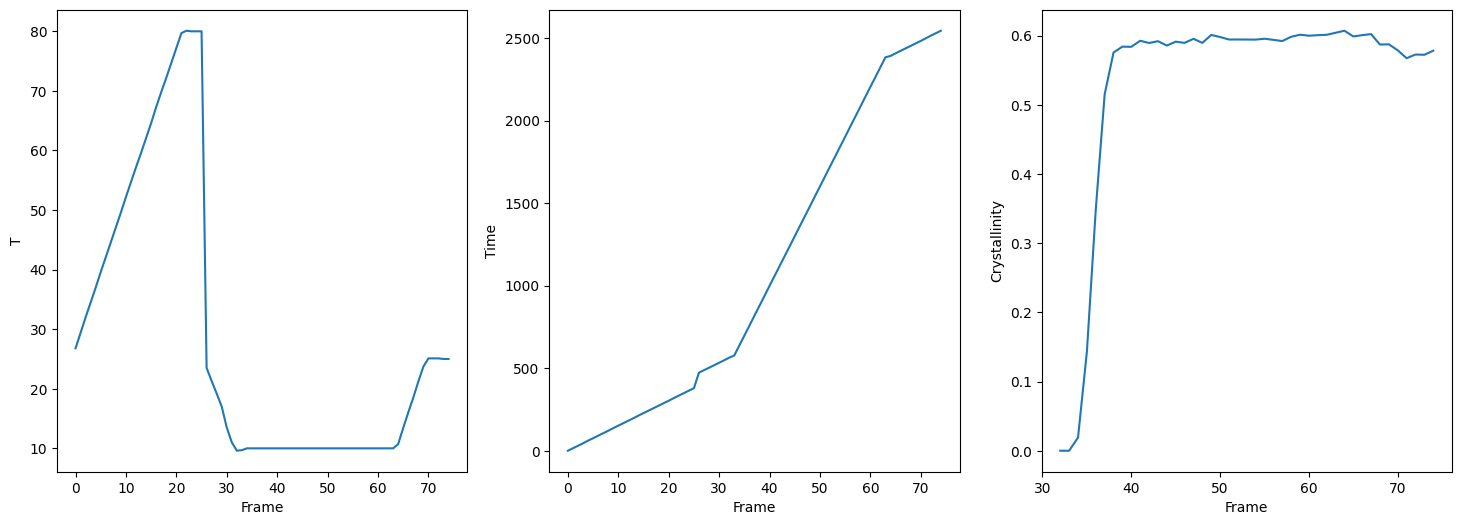

In [155]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_12_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

NameError: name 'Exp292_12_10C' is not defined

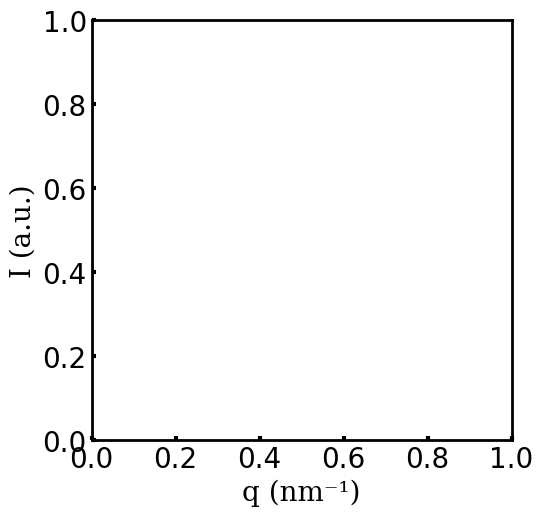

In [2]:
WAXS_plot(6,6)
Exp = Exp292_12_10C
lnwdth = 3
k = 0.2

q, I = Exp.get_1d_WAXS(32)
plt.plot(q, I/1000+0.1, linewidth=lnwdth, color='#D53302')

q, I = Exp.get_1d_WAXS(34)
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360')

q, I = Exp.get_1d_WAXS(35)
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp.get_1d_WAXS(36)
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD')

q, I = Exp.get_1d_WAXS(40)
plt.plot(q, I/1000+ k*4,   linewidth=lnwdth, color='#00012A')

plt.xlim(9, 21)
plt.ylim(-0.1, 3.6)

Чтение SAXS файла 32: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0032.dat
Чтение SAXS файла 34: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0034.dat
Чтение SAXS файла 35: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0035.dat
Чтение SAXS файла 36: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0036.dat
Чтение SAXS файла 40: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0040.dat


(0.005, 2000.0)

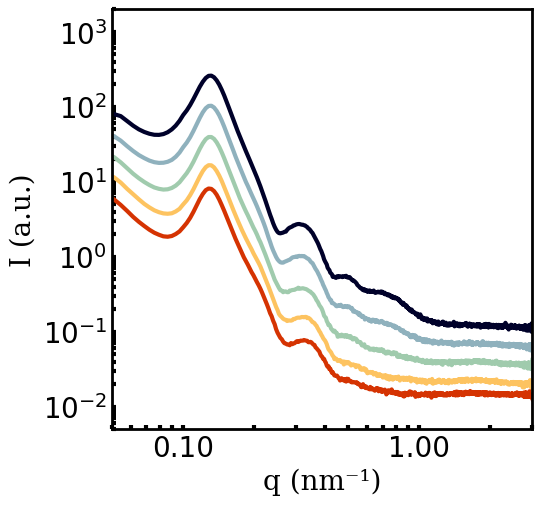

In [117]:
SAXS_plot(6,6)
Exp = Exp292_12_10C
lnwdth = 3
k = 1.8

q, I = Exp.get_1d_SAXS(32)
plt.plot(q, I/1.1, linewidth=lnwdth, color='#D53302')

q, I = Exp.get_1d_SAXS(34)
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360')

q, I = Exp.get_1d_SAXS(35)
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp.get_1d_SAXS(36)
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD')

q, I = Exp.get_1d_SAXS(40)
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A')

plt.xlim(0.05, 3)
plt.ylim(0.5e-2, 20e2)

In [161]:
Info.iloc[38]

Time            878.000000
Temperature      10.000000
Crystalinity      0.575611
D 120            22.288359
D 032            12.913316
q1_Ampl           0.000000
Name: 38, dtype: float64

In [136]:
fig, ax1 = plt.subplots(figsize=(6,6))

color = '#FF6A3D'
ax1.set_xlabel('Time (s)', fontdict = font)
ax1.set_ylabel('BB peak amplitude (a.u.)', color=color, fontdict = font)
ax1.scatter(Time-564.000000, q1_I/0.005, color=color, s=150)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = '#8FB1BD'
ax2.set_ylabel('Crystallinity', color=color, fontdict = font)  # we already handled the x-label with ax1
ax2.scatter(Time-900, Cr, color=color, s=150)
ax2.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.tick_params(axis="both",which='both',direction="in", width=3, length=3, labelsize=20)
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.tick_params(axis="both",which='both',direction="in", width=3, length=3, labelsize=20)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

#plt.tight_layout(pad=3.0)
ax1.set_ylim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.xlim(-10, 1609)

ax1.set_position([0.15, 0.15, 0.7, 0.7])
ax2.set_position([0.15, 0.15, 0.7, 0.7])
plt.show()

<function __main__.Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s)>

Чтение SAXS файла 40: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0040.dat


array([1.49205642e-06, 1.71414646e+01, 1.19305052e-01, 1.06023102e-02,
       1.21810428e-02, 7.08490026e-01, 2.08107123e-01])

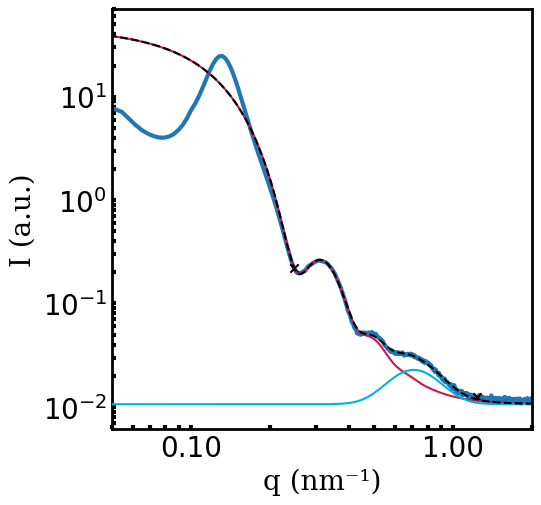

In [154]:
SAXS_plot(6,6)

q, I = Exp292_12_10C.get_1d_SAXS(40)
plt.plot(q, I, linewidth=3)

l = 70
r = 350
plt.scatter(q[l], I[l], marker='x', zorder=10, color='black')
plt.scatter(q[r], I[r], marker='x', zorder=10, color='black')
#plt.plot(q[l:r], Spheres_log_norm(q[l:r],1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ))
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 18, 0.12, 8.91806121e-03,  5.32180981e-03, 0.7, 0.2 ])
#p0 = [2.25499627e-06, 12, 0.1, 3e-2]
#plt.plot(q[l:r], model(q[l:r], *p0))
plt.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit')
plt.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#c9184a', zorder=11, label = 'Form-Factor')
plt.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#00b4d8', zorder=12, label='Log-Norm peak')

plt.xlim(0.05, 2)
p

In [171]:
Spheres_log_norm

<function __main__.Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s)>

In [206]:
Params_df = pd.DataFrame({'frame':range(60, 32, -1), 'Ravg':np.zeros(28), 'q0':np.zeros(28), 'p':np.zeros(28)})
Params_array = []
p0 = [1.49205642e-06, 1.71414646e+01, 1.19305052e-01, 1.06023102e-02,
       1.21810428e-02, 7.08490026e-01, 2.08107123e-01]

j = 0
for i in Params_df['frame']:
    print(i)
    q, I = Exp292_12_10C.get_1d_SAXS(i)

    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0)
    Params_array.append(p)
    Params_df['Ravg'].iloc[j] = p[1]
    
    Params_df['q0'].iloc[j] = p[5]
    Params_df['p'].iloc[j] = p[2]
    j += 1
    p0 = p


60
Чтение SAXS файла 60: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0060.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: SettingWithCopyWarning: 
A

59
Чтение SAXS файла 59: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0059.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: SettingWithCopyWarning: 
A

58
Чтение SAXS файла 58: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0058.dat


...

C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: SettingWithCopyWarning: 
A

34
Чтение SAXS файла 34: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0034.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: SettingWithCopyWarning: 
A

33
Чтение SAXS файла 33: PEG_PNIPAM_292_12_Cryst_at_10C_SAXS_0033.dat


C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Params_df['Ravg'].iloc[j] = p[1]
C:\Users\LabPC\AppData\Local\Temp\ipykernel_12400\2916250556.py:13: SettingWithCopyWarning: 
A

array([ 1.71481284e+01,  1.08204965e-02, -2.52537932e+02])

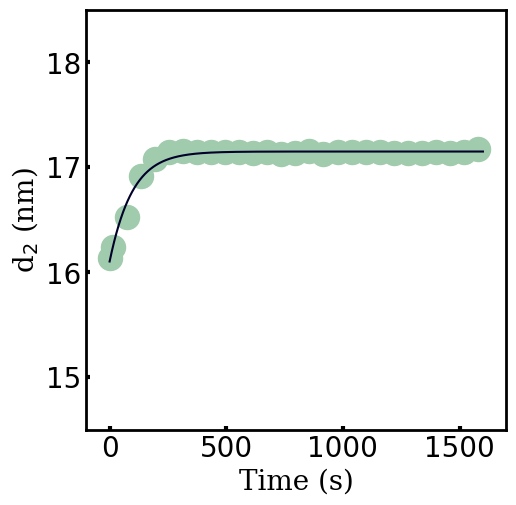

In [223]:
fig, ax = plt.subplots(figsize=(6, 6))
font = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }
linewidth = 3
k = 1
ax.set_position([0.15, 0.15, 0.7, 0.7])

plt.scatter(Info['Time'][32:60][::-1] - 564, Params_df['Ravg'], s = 300,color='#A0CBAD')

p, cov = curve_fit(sigmoid, Info['Time'][32:60][::-1] - 564, Params_df['Ravg'], p0=[17, 0.1, 0])
plt.plot(np.linspace(0, 1600, 1000), sigmoid(np.linspace(0, 1600, 1000), *p), color='#00012A')

plt.xlabel('Time (s)', fontdict = font)
plt.ylabel('d${_2}$ (nm)', fontdict = font)

#ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)
#ax.minorticks_off()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_position([0.15, 0.15, 0.7, 0.7])
#plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax.set_xlabel('Time (s)', fontdict = font)
ax.tick_params(axis="both",which='both',direction="in", width=3, length=3, labelsize=20)
#plt.yticks([10.5, 11, 11.5, 12])
#plt.xticks([0, 500, 1000, 1500])
plt.xlim(-100, 1700)
#plt.ylim(10.3, 12.1)
plt.ylim(14.5, 18.5)
p

In [226]:
2*np.pi/0.13

48.3321946706122

### 292-24 10C

Text(0, 0.5, 'Crystallinity')

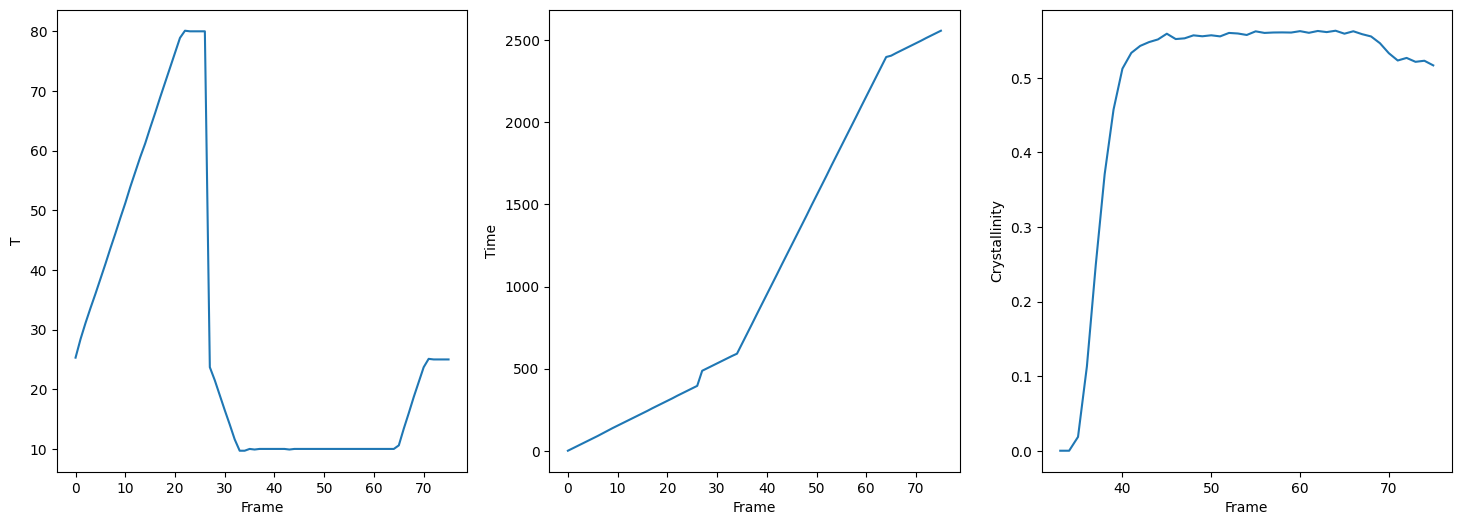

In [76]:
fig, ax = plt.subplots(1,3, figsize=(18, 6))
Info = Info292_24_10C
length = len(Info['Temperature'])

ax[0].plot(range(length), Info['Temperature'])
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('T')
ax[1].plot(range(length), Info['Time'])
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Time')
ax[2].plot(range(length), Info['Crystalinity'])
ax[2].set_xlabel('Frame')
ax[2].set_ylabel('Crystallinity')
#plt.plot(range(len(Info['Temperature'])), Info['Time'])
#plt.plot(range(len(Info['Temperature'])), Info['Crystalinity'])

Чтение WAXS файла 34: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0034.dat
Чтение WAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0035.dat
Чтение WAXS файла 36: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0036.dat
Чтение WAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0037.dat
Чтение WAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_WAXS_0040.dat


(-0.1, 6.0)

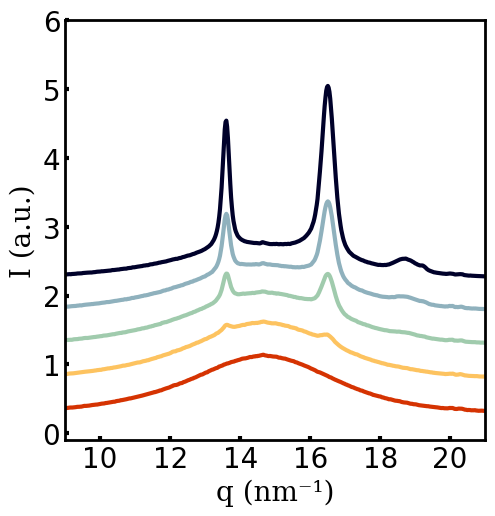

In [122]:
WAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 0.5

q, I = Exp.get_1d_WAXS(34)
plt.plot(q, I/1000, linewidth=lnwdth, color='#D53302')

q, I = Exp.get_1d_WAXS(35)
plt.plot(q, I/1000+ k*1, linewidth=lnwdth, color='#FDC360')

q, I = Exp.get_1d_WAXS(36)
plt.plot(q, I/1000+ k*2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp.get_1d_WAXS(37)
plt.plot(q, I/1000+ k*3, linewidth=lnwdth, color='#8FB1BD')

q, I = Exp.get_1d_WAXS(40)
plt.plot(q, I/1000+ k*4,   linewidth=lnwdth, color='#00012A')

plt.xlim(9, 21)
plt.ylim(-0.1, 6)

Чтение SAXS файла 34: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0034.dat
Чтение SAXS файла 35: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0035.dat
Чтение SAXS файла 36: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0036.dat
Чтение SAXS файла 37: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0037.dat
Чтение SAXS файла 40: PEG_PNIPAM_292_24_Cryst_at_10C_SAXS_0040.dat


(0.011, 8000.0)

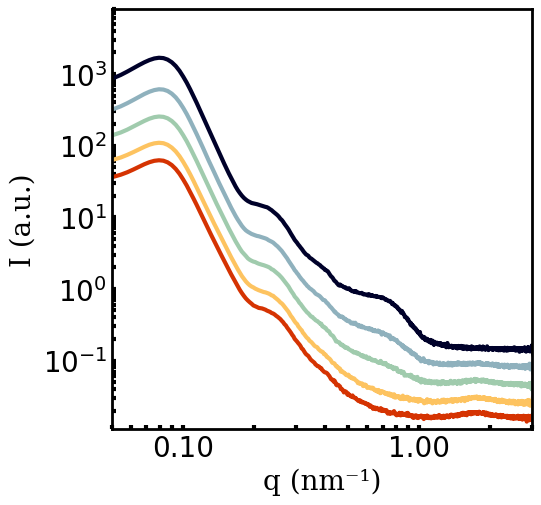

In [123]:
SAXS_plot(6,6)
Exp = Exp292_24_10C
lnwdth = 3
k = 1.8

q, I = Exp.get_1d_SAXS(34)
plt.plot(q, I * 1.1, linewidth=lnwdth, color='#D53302')

q, I = Exp.get_1d_SAXS(35)
plt.plot(q, I * k ** 1, linewidth=lnwdth, color='#FDC360')

q, I = Exp.get_1d_SAXS(36)
plt.plot(q, I * k ** 2, linewidth=lnwdth, color='#A0CBAD')

q, I = Exp.get_1d_SAXS(37)
plt.plot(q, I * k ** 3 , linewidth=lnwdth, color='#8FB1BD')

q, I = Exp.get_1d_SAXS(40)
plt.plot(q, I * k ** 4, linewidth=lnwdth, color='#00012A')

plt.xlim(0.05, 3)
plt.ylim(1.1e-2, 8e3)